# Example 2

In [1]:
import rapidsegment as rs
from prettytable import PrettyTable
import pandas as pd
from rapidsegment import UniversalDataLoader
from rapidsegment import StrategicSegmentBuilder
from rapidsegment import StrategicSegmentScore
import duckdb
import pyarrow as pa
import os
import matplotlib.pyplot as plt
pd.options.display.max_columns = 100

In [2]:
print(f"RapidSegment version: {rs.__version__}")

RapidSegment version: 1.3.3


# LOAD DATA

In [3]:
data = UniversalDataLoader(file_path=r"D:\RapidSegment\RapidSegment\Notebooks\Term_Deposit_Sub\bank_train.csv", ).load()
print(f"Loaded as {type(data)} table for better performance ")
data.slice(0,5).to_pandas()

2026-09-20 21:29:54,922 | INFO     | [data_loader.py:151] | 📂 Loading file: D:\RapidSegment\RapidSegment\Notebooks\Term_Deposit_Sub\bank_train.csv (extension: .csv)


Loaded as <class 'pyarrow.lib.Table'> table for better performance 


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,46.0,blue-collar,married,primary,no,-339.0,yes,yes,cellular,11.0,may,182.0,2.0,-1.0,0.0,unknown,no
1,38.0,management,married,tertiary,no,0.0,yes,no,cellular,30.0,apr,571.0,1.0,-1.0,0.0,unknown,yes
2,32.0,management,single,tertiary,no,1804.0,yes,no,unknown,20.0,jun,73.0,3.0,-1.0,0.0,unknown,no
3,46.0,admin.,divorced,primary,no,1807.0,yes,no,cellular,11.0,may,62.0,3.0,339.0,2.0,failure,no
4,53.0,entrepreneur,married,tertiary,no,0.0,no,no,cellular,20.0,nov,520.0,2.0,-1.0,0.0,unknown,no


#### Notes
- Here income is the target variable. But we see that it is not one hot encoded or not binary in nature.
- We need to binarize the variable before we proceed to segment creation

# Binarizing Target Variable
    Using duckdb SQL native syntax to perform the binarization

In [4]:
# specify a database file path for persistence
db_file = "dataset.duckdb"

# connect to the duckdb database file (creates it if it doesn't exist)
# read_only=False is important for writing/modifying data
con = duckdb.connect(database=db_file, read_only=False)

# register the pyarrow table as a virtual table named 'original_data'
# duckdb can query this table as if it were a native table in the db
duckdb_data_var = "original_data"
con.register(duckdb_data_var, data)

print(f"\nduckdb database connected and persisted to: {db_file}")
print(f"pyarrow table registered as {duckdb_data_var}")


duckdb database connected and persisted to: dataset.duckdb
pyarrow table registered as original_data


In [5]:
# define the sql query
# this converts 'active' status to 1, and all other statuses to 0
target_col = "y"
sql_query = f"""
SELECT
    *,
    CASE WHEN {target_col} = 'yes' THEN 1 ELSE 0 END AS {target_col}_binary
FROM
    {duckdb_data_var}
"""

# execute the query and fetch the result directly as a pyarrow table
mod_data = con.execute(sql_query).arrow()
mod_data = pa.Table.from_batches(mod_data)
print("\nduckdb query executed. result as pyarrow table:")
mod_data.slice(0,5).to_pandas()


duckdb query executed. result as pyarrow table:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary
0,46.0,blue-collar,married,primary,no,-339.0,yes,yes,cellular,11.0,may,182.0,2.0,-1.0,0.0,unknown,no,0
1,38.0,management,married,tertiary,no,0.0,yes,no,cellular,30.0,apr,571.0,1.0,-1.0,0.0,unknown,yes,1
2,32.0,management,single,tertiary,no,1804.0,yes,no,unknown,20.0,jun,73.0,3.0,-1.0,0.0,unknown,no,0
3,46.0,admin.,divorced,primary,no,1807.0,yes,no,cellular,11.0,may,62.0,3.0,339.0,2.0,failure,no,0
4,53.0,entrepreneur,married,tertiary,no,0.0,no,no,cellular,20.0,nov,520.0,2.0,-1.0,0.0,unknown,no,0


# Setup Experiment

Naive path


In [6]:
param_grid = {'min_sample_size': [20000, 15000, 10000, 5000, 500],'min_lift': [3.0, 2.0, 1.5]}
builder = StrategicSegmentBuilder(target = target_col+'_binary',
                                  min_sample_size = 100,
                                  min_lift = 1.0, 
                                  min_events  = 50, 
                                  top_n_vars = 10,
                                  max_segments = 10,
                                  param_grid = param_grid,
                                  enable_diversity = False, 
                                  max_feature_reuse = 5, 
                                  enable_1way = True,
                                  enable_2way = True,
                                  enable_3way = True,
                                  feature_groups = None,
                                  ignore_features = [target_col],
                                  sort_priority = 'lift_rate_count',
                                  binning_method="optimal_cart",
                                  selection_metric='iv',)

#### Rule Mining

In [7]:
segments_df = builder.extract_segments(mod_data)

2026-09-20 21:29:55,146 | INFO     | [builder.py:1299] | 🚀 Starting hierarchical segment extraction...
2026-09-20 21:29:55,149 | INFO     | [builder.py:1324] | 📂 Created temporary disk-backed DB at: C:\Users\BISHWA~1\AppData\Local\Temp\rapidsegment_f921202b\segmentation_20260920_eff1ad1f.duckdb
2026-09-20 21:29:55,180 | INFO     | [builder.py:303] | ⚙️ DuckDB Configured: Threads=14/16, MemoryLimit=11GB, TempDir=C:\Users\BISHWA~1\AppData\Local\Temp\rapidsegment_f921202b\tmp_20260920_eff1ad1f
2026-09-20 21:29:55,181 | INFO     | [builder.py:1328] | 📊 Sort priority: lift_rate_count
2026-09-20 21:29:55,182 | INFO     | [builder.py:1329] | 📦 Binning method: optimal_cart
2026-09-20 21:29:55,312 | INFO     | [builder.py:1412] | 📊 Dynamic Grid Search Enabled: 15 configurations.
2026-09-20 21:29:55,316 | INFO     | [builder.py:1420] | 🔒 Locking Original Base Rate: 11.70%
2026-09-20 21:29:55,318 | INFO     | [builder.py:1446] | 🔄 Iteration 1 | Remaining Volume: 40,689 | Base Rate: 11.70%
2026-09

### Segment Evaluation

In [8]:
final_eval = builder.evaluate_final_coverage(mod_data)

2026-09-20 21:30:12,276 | INFO     | [builder.py:1868] | 📊 Evaluating final hierarchical coverage on original data...
2026-09-20 21:30:12,303 | INFO     | [builder.py:303] | ⚙️ DuckDB Configured: Threads=14/16, MemoryLimit=11GB, TempDir=<none>


# Final Segment Report

In [9]:

table = PrettyTable()
table.field_names = list(pd.DataFrame(final_eval).columns)
for _, row in pd.DataFrame(final_eval).iterrows():
    table.add_row(list(row))
print(table)

+---------+-------------+---------------+--------------------+--------------------+--------------------+--------------------+---------------------------+--------------------------+
| segment | total_count | target_events |   response_rate    | base_response_rate |    capture_rate    |        lift        | cumulative_sample_capture | cumulative_event_capture |
+---------+-------------+---------------+--------------------+--------------------+--------------------+--------------------+---------------------------+--------------------------+
|   1.0   |    506.0    |     317.0     | 62.648221343873516 | 11.698493450318267 | 1.2435793457691269 | 5.3552383997077095 |     1.2435793457691269    |    6.659663865546219     |
|   2.0   |    739.0    |     442.0     | 59.810554803788904 | 11.698493450318267 | 1.8162156848288236 | 5.1126715638894265 |      3.05979503059795     |    15.945378151260504    |
|   3.0   |    650.0    |     368.0     | 56.61538461538461  | 11.698493450318267 | 1.597483349

# Segment SQL definition

In [10]:
print("--- FULL SEGMENT RULES ---\n")

for index, row in pd.DataFrame(segments_df).iterrows():
    print(f"Segment ID: {row['segment_id']}")
    print(f"Raw Rule:   {row['rule_string']}")
    print(f"SQL Filter: {row['sql_filter']}")
    print("-" * 50)

--- FULL SEGMENT RULES ---

Segment ID: 1
Raw Rule:   housing=[no] & month=[apr, oct, dec, sep, mar] & poutcome=[other, success]
SQL Filter: ("housing" IN ('no')) AND ("month" IN ('apr', 'oct', 'dec', 'sep', 'mar')) AND ("poutcome" IN ('other', 'success'))
--------------------------------------------------
Segment ID: 2
Raw Rule:   contact=[cellular] & duration=[702.50, inf) & housing=[no]
SQL Filter: ("contact" IN ('cellular')) AND ("duration" >= 702.50) AND ("housing" IN ('no'))
--------------------------------------------------
Segment ID: 3
Raw Rule:   housing=[no] & pdays=[9.50, 187.50) & poutcome=[other, success]
SQL Filter: ("housing" IN ('no')) AND ("pdays" >= 9.50 AND "pdays" < 187.50) AND ("poutcome" IN ('other', 'success'))
--------------------------------------------------
Segment ID: 4
Raw Rule:   contact=[cellular] & duration=[647.50, inf) & previous=(-inf, 0.50)
SQL Filter: ("contact" IN ('cellular')) AND ("duration" >= 647.50) AND ("previous" < 0.50)
-------------------

##### Segment Meta informations
-  We can see the raw string and the parsed sql here in the below table.
- We can also see what hyper parameters were satisfied to mine the segment

In [11]:

table = PrettyTable()
table.field_names = list(pd.DataFrame(segments_df).columns)
for _, row in pd.DataFrame(segments_df).iterrows():
    table.add_row(list(row))
print(table)

+------------+----------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------+-------+--------------------+--------------------+--------------------------+-----------------------+
| segment_id |                                rule_string                                 |                                                      sql_filter                                                     | count |        rate        |        lift        | meta_applied_sample_size | meta_applied_min_lift |
+------------+----------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------+-------+--------------------+--------------------+--------------------------+-----------------------+
|     1      | housing=[no] & month=[apr, oct, dec, sep, mar] & pou

# Diagnostics

- Check why no futher segments were generated

In [12]:
print(builder.explain_no_segments())

SEGMENT EXTRACTION DIAGNOSTIC REPORT
Segments Extracted : 10 / 10
Iterations Run     : 10
Stop Reason        : Reached max_segments limit (10).
--------------------------------------------------------------------------------
Active Constraints:
  - min_sample_size : 100
  - min_lift        : 1.00x
  - min_events      : 50
  - selection_metric: iv

Feature Eligibility Summary (Iteration 10):
  - 9   feature(s): Eligible for Combination Search
  - 4   feature(s): Excluded (Outside Top N Features by Score)
  - 2   feature(s): Excluded (Max Feature Reuse Exceeded)
  - 1   feature(s): Excluded (IV is Zero/Invalid)

Candidate Funnel (Iteration 10):
  - 1-way candidates passing base criteria : 41
  - 2-way candidates passing base criteria : 262
  - 3-way candidates passing base criteria : 497
  - Total candidates before grid search   : 800
  - Candidates clearing grid filter       : 1



##### Check why a feature was selected/not selected
- Here we see that AGE was never selected
- As observed, it was eligible for search combination but during rule discovery, it was either not able to pass hard constraints or other candidates were better in terms of selection criteria hence it was ranked lower and not selected


In [13]:
builder.explain_feature_journey("age")

📌 AUDIT TRAIL FOR FEATURE: 'age'

[Iteration 1]
  • Current dynamic IV   : 0.1550
  • Previous times used  : 0
  • Selection Status     : Eligible for Combination Search
  • Winner this round    : housing=[no] & month=[apr, oct, dec, sep, mar] & poutcome=[other, success] (Variables: ['housing', 'month', 'poutcome'])

[Iteration 2]
  • Current dynamic IV   : 0.1445
  • Previous times used  : 0
  • Selection Status     : Eligible for Combination Search
  • Winner this round    : contact=[cellular] & duration=[702.50, inf) & housing=[no] (Variables: ['contact', 'duration', 'housing'])

[Iteration 3]
  • Current dynamic IV   : 0.1612
  • Previous times used  : 0
  • Selection Status     : Eligible for Combination Search
  • Winner this round    : housing=[no] & pdays=[9.50, 187.50) & poutcome=[other, success] (Variables: ['housing', 'pdays', 'poutcome'])

[Iteration 4]
  • Current dynamic IV   : 0.1433
  • Previous times used  : 0
  • Selection Status     : Eligible for Combination Search


# Preparing the dataset for scoring and decile banding.
- Only score when atleast 10 segments are found

In [14]:
# define the sql query
# this converts 'active' status to 1, and all other statuses to 0
sql_query = f"""
SELECT *, 
 -- Segment 1 match
    CASE
        WHEN ("housing" IN ('no')) AND ("month" IN ('apr', 'oct', 'dec', 'sep', 'mar')) AND ("poutcome" IN ('other', 'success')) THEN 1
        ELSE 0
    END AS seg_1,

    -- Segment 2 match
    CASE
        WHEN ("contact" IN ('cellular')) AND ("duration" >= 702.50) AND ("housing" IN ('no')) THEN 1
        ELSE 0
    END AS seg_2,

    -- Segment 3 match
    CASE
        WHEN ("housing" IN ('no')) AND ("pdays" >= 9.50 AND "pdays" < 187.50) AND ("poutcome" IN ('other', 'success')) THEN 1
        ELSE 0
    END AS seg_3,

    -- Segment 4 match
    CASE
        WHEN ("contact" IN ('cellular')) AND ("duration" >= 647.50) AND ("previous" < 0.50) THEN 1
        ELSE 0
    END AS seg_4,

    -- Segment 5 match
    CASE
        WHEN ("duration" >= 471.50) AND ("poutcome" IN ('failure', 'success')) THEN 1
        ELSE 0
    END AS seg_5,

    -- Segment 6 match
    CASE
        WHEN ("contact" IN ('cellular')) AND ("housing" IN ('no')) AND ("month" IN ('apr', 'oct', 'sep', 'dec', 'mar')) THEN 1
        ELSE 0
    END AS seg_6,

    -- Segment 7 match
    CASE
        WHEN ("contact" IN ('cellular')) AND ("month" IN ('jun')) THEN 1
        ELSE 0
    END AS seg_7,

    -- Segment 8 match
    CASE
        WHEN ("campaign" < 1.50) AND ("duration" >= 511.50) THEN 1
        ELSE 0
    END AS seg_8,

    -- Segment 9 match
    CASE
        WHEN ("duration" >= 472.50) AND ("housing" IN ('no')) AND ("previous" < 0.50) THEN 1
        ELSE 0
    END AS seg_9,

    -- Segment 10 match
    CASE
        WHEN ("job" IN ('management')) AND ("month" IN ('feb', 'oct', 'dec', 'sep', 'mar')) THEN 1
        ELSE 0
    END AS seg_10,                                                                            
ROW_NUMBER() OVER () AS ID,
FROM mod_data
"""

# execute the query and fetch the result directly as a pyarrow table
pred_data = con.execute(sql_query).arrow()
pred_data = pa.Table.from_batches(pred_data)
print("\nduckdb query executed. result as pyarrow table:")
pred_data.slice(0,5).to_pandas()


duckdb query executed. result as pyarrow table:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary,seg_1,seg_2,seg_3,seg_4,seg_5,seg_6,seg_7,seg_8,seg_9,seg_10,ID
0,46.0,blue-collar,married,primary,no,-339.0,yes,yes,cellular,11.0,may,182.0,2.0,-1.0,0.0,unknown,no,0,0,0,0,0,0,0,0,0,0,0,1
1,38.0,management,married,tertiary,no,0.0,yes,no,cellular,30.0,apr,571.0,1.0,-1.0,0.0,unknown,yes,1,0,0,0,0,0,0,0,1,0,0,2
2,32.0,management,single,tertiary,no,1804.0,yes,no,unknown,20.0,jun,73.0,3.0,-1.0,0.0,unknown,no,0,0,0,0,0,0,0,0,0,0,0,3
3,46.0,admin.,divorced,primary,no,1807.0,yes,no,cellular,11.0,may,62.0,3.0,339.0,2.0,failure,no,0,0,0,0,0,0,0,0,0,0,0,4
4,53.0,entrepreneur,married,tertiary,no,0.0,no,no,cellular,20.0,nov,520.0,2.0,-1.0,0.0,unknown,no,0,0,0,0,0,0,0,0,0,1,0,5


# Score the segments on the dataset and create decile bands


In [15]:
scorer = StrategicSegmentScore(
    target_col=target_col+'_binary',
    primary_key="ID",
    segment_cols=["seg_1","seg_2",'seg_3','seg_4','seg_5','seg_6','seg_7','seg_8','seg_9','seg_10'],
)

##### Export Segment Score as JSON

In [16]:
model_artifact = scorer.calculate_and_export_weights(pred_data)

2026-09-20 21:30:12,593 | INFO     | [scorer.py:87] | 🚀 Initialising out‑of‑core DuckDB scorecard engine...
2026-09-20 21:30:12,732 | INFO     | [scorer.py:154] | 📊 Computing scorecard weights...
2026-09-20 21:30:12,733 | INFO     | [scorer.py:207] | ✅ Scorecard has 10 distinct score values – good for deciling.
2026-09-20 21:30:12,733 | INFO     | [scorer.py:212] | ⚡ Scoring population natively via SQL engine...
2026-09-20 21:30:12,742 | INFO     | [scorer.py:232] | 📉 Dataset Zero‑Inflation Rate: 88.30%
2026-09-20 21:30:12,743 | INFO     | [scorer.py:237] | 📈 Calibrating deciles across active populations...
2026-09-20 21:30:12,749 | INFO     | [scorer.py:285] | ✅ Scorecard exported to: scored_experiment_2026_09_20_21_29_54.json


##### View segment score and create final Decile based summary

In [17]:
for key, value in model_artifact.get("segment_weights").items():
    print(f"Segment: {key} | Weight: {value['weight']}")

Segment: seg_1 | Weight: 63
Segment: seg_2 | Weight: 60
Segment: seg_3 | Weight: 61
Segment: seg_4 | Weight: 55
Segment: seg_5 | Weight: 54
Segment: seg_6 | Weight: 48
Segment: seg_7 | Weight: 44
Segment: seg_8 | Weight: 46
Segment: seg_9 | Weight: 43
Segment: seg_10 | Weight: 36


In [18]:
model_artifact.get("decile_min_thresholds")

{'1': 158,
 '2': 105,
 '3': 89,
 '4': 61,
 '5': 54,
 '6': 48,
 '7': 46,
 '8': 44,
 '9': 43,
 '10': 36}

# Scoring on Entire Dataset

In [19]:
sql_query = f"""
WITH CTE AS (
SELECT *, 
CASE WHEN seg_1 = 1 THEN 63 ELSE 0 END AS seg_1_weighted,
CASE WHEN seg_2 = 1 THEN 60 ELSE 0 END AS seg_2_weighted,
CASE WHEN seg_3 = 1 THEN 61 ELSE 0 END AS seg_3_weighted,
CASE WHEN seg_4 = 1 THEN 55 ELSE 0 END AS seg_4_weighted,
CASE WHEN seg_5 = 1 THEN 54 ELSE 0 END AS seg_5_weighted,
CASE WHEN seg_6 = 1 THEN 48 ELSE 0 END AS seg_6_weighted,
CASE WHEN seg_7 = 1 THEN 44 ELSE 0 END AS seg_7_weighted,
CASE WHEN seg_8 = 1 THEN 46 ELSE 0 END AS seg_8_weighted,
CASE WHEN seg_9 = 1 THEN 43 ELSE 0 END AS seg_9_weighted,
CASE WHEN seg_10 = 1 THEN 36 ELSE 0 END AS seg_10_weighted,
FROM pred_data),
CTE2 AS (
SELECT *, (COALESCE(seg_1_weighted,0) + COALESCE(seg_2_weighted,0) + COALESCE(seg_3_weighted,0) 
+ COALESCE(seg_4_weighted,0) + COALESCE(seg_5_weighted,0) + COALESCE(seg_6_weighted,0) + COALESCE(seg_7_weighted,0) 
+ COALESCE(seg_8_weighted,0) + COALESCE(seg_9_weighted,0) + COALESCE(seg_10_weighted,0) ) AS total_weight
FROM CTE)
SELECT *, CASE 
WHEN total_weight >= 158 THEN 1
WHEN total_weight >= 105 THEN 2
WHEN total_weight >= 89 THEN 3
WHEN total_weight >= 61 THEN 4
WHEN total_weight >= 54 THEN 5
WHEN total_weight >= 48 THEN 6
WHEN total_weight >= 46 THEN 7
WHEN total_weight >= 44 THEN 8
WHEN total_weight >= 43 THEN 9
WHEN total_weight >= 36 THEN 10
ELSE 0 END AS decile_band

FROM CTE2
"""

# execute the query and fetch the result directly as a pyarrow table
pred_data = con.execute(sql_query).arrow()
pred_data = pa.Table.from_batches(pred_data)

In [20]:
revised_target_col = target_col+'_binary'

In [21]:
decile = con.execute(f"""SELECT decile_band, 
                    COUNT(*) AS count, 
                    SUM({revised_target_col}) AS events, 
                    (SUM({revised_target_col})*100.0/COUNT(*)) AS response_rate
FROM pred_data
GROUP BY decile_band
ORDER BY decile_band
""").arrow()
decile = pa.Table.from_batches(decile)


## Check the Decile bands wise response rate

In [22]:
decile.to_pandas()


,decile_band,count,events,response_rate
0,0,33385,1550,4.642804
1,1,1098,684,62.295082
2,2,391,236,60.358056
3,3,912,453,49.671053
4,4,736,365,49.592391
5,5,750,359,47.866667
6,6,995,396,39.798995
7,7,565,174,30.796460
8,8,501,179,35.728543
9,9,801,239,29.837703


# Predict on Unseen data

1. Load Data
2. Prepare Data for scoring

In [23]:
data = UniversalDataLoader(file_path=r"D:\RapidSegment\RapidSegment\Notebooks\Term_Deposit_Sub\bank_test.csv", ).load()
print(f"Loaded as {type(data)} table for better performance ")
data.slice(0,5).to_pandas()

2026-09-20 21:30:13,012 | INFO     | [data_loader.py:151] | 📂 Loading file: D:\RapidSegment\RapidSegment\Notebooks\Term_Deposit_Sub\bank_test.csv (extension: .csv)


Loaded as <class 'pyarrow.lib.Table'> table for better performance 


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,55.0,unknown,married,tertiary,no,0.0,no,no,unknown,16.0,may,409.0,3.0,-1.0,0.0,unknown,no
1,41.0,entrepreneur,divorced,tertiary,no,-413.0,yes,no,unknown,8.0,may,170.0,2.0,-1.0,0.0,unknown,no
2,58.0,management,divorced,tertiary,no,347.0,no,no,unknown,15.0,may,525.0,1.0,-1.0,0.0,unknown,no
3,27.0,management,single,tertiary,no,317.0,no,no,cellular,9.0,feb,59.0,3.0,-1.0,0.0,unknown,no
4,32.0,housemaid,married,secondary,no,3832.0,no,no,cellular,11.0,aug,80.0,3.0,-1.0,0.0,unknown,no


In [24]:
# register the pyarrow table as a virtual table named 'original_data'
# duckdb can query this table as if it were a native table in the db
duckdb_data_var = "test_data"
con.register(duckdb_data_var, data)

print(f"\nduckdb database connected and persisted to: {db_file}")
print(f"pyarrow table registered as {duckdb_data_var}")


duckdb database connected and persisted to: dataset.duckdb
pyarrow table registered as test_data


- Since we have target labels for validation we are going to binarize that accordingly

In [25]:
# define the sql query
# this converts 'active' status to 1, and all other statuses to 0
target_col = "y"
sql_query = f"""
SELECT
    *,
    CASE WHEN {target_col} = 'yes' THEN 1 ELSE 0 END AS {target_col}_binary
FROM
    {duckdb_data_var}
"""

# execute the query and fetch the result directly as a pyarrow table
mod_data_test = con.execute(sql_query).arrow()
mod_data_test = pa.Table.from_batches(mod_data_test)
print("\nduckdb query executed. result as pyarrow table:")
mod_data_test.slice(0,5).to_pandas()


duckdb query executed. result as pyarrow table:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary
0,55.0,unknown,married,tertiary,no,0.0,no,no,unknown,16.0,may,409.0,3.0,-1.0,0.0,unknown,no,0
1,41.0,entrepreneur,divorced,tertiary,no,-413.0,yes,no,unknown,8.0,may,170.0,2.0,-1.0,0.0,unknown,no,0
2,58.0,management,divorced,tertiary,no,347.0,no,no,unknown,15.0,may,525.0,1.0,-1.0,0.0,unknown,no,0
3,27.0,management,single,tertiary,no,317.0,no,no,cellular,9.0,feb,59.0,3.0,-1.0,0.0,unknown,no,0
4,32.0,housemaid,married,secondary,no,3832.0,no,no,cellular,11.0,aug,80.0,3.0,-1.0,0.0,unknown,no,0


### Scoring on unseen data

In [26]:
sql_query = f"""
WITH CTE AS (SELECT *, 
-- Segment 1 match
CASE
    WHEN ("housing" IN ('no')) AND ("month" IN ('apr', 'oct', 'dec', 'sep', 'mar')) AND ("poutcome" IN ('other', 'success')) THEN 1
    ELSE 0
END AS seg_1,

-- Segment 2 match
CASE
    WHEN ("contact" IN ('cellular')) AND ("duration" >= 702.50) AND ("housing" IN ('no')) THEN 1
    ELSE 0
END AS seg_2,

-- Segment 3 match
CASE
    WHEN ("housing" IN ('no')) AND ("pdays" >= 9.50 AND "pdays" < 187.50) AND ("poutcome" IN ('other', 'success')) THEN 1
    ELSE 0
END AS seg_3,

-- Segment 4 match
CASE
    WHEN ("contact" IN ('cellular')) AND ("duration" >= 647.50) AND ("previous" < 0.50) THEN 1
    ELSE 0
END AS seg_4,

-- Segment 5 match
CASE
    WHEN ("duration" >= 471.50) AND ("poutcome" IN ('failure', 'success')) THEN 1
    ELSE 0
END AS seg_5,

-- Segment 6 match
CASE
    WHEN ("contact" IN ('cellular')) AND ("housing" IN ('no')) AND ("month" IN ('apr', 'oct', 'sep', 'dec', 'mar')) THEN 1
    ELSE 0
END AS seg_6,

-- Segment 7 match
CASE
    WHEN ("contact" IN ('cellular')) AND ("month" IN ('jun')) THEN 1
    ELSE 0
END AS seg_7,

-- Segment 8 match
CASE
    WHEN ("campaign" < 1.50) AND ("duration" >= 511.50) THEN 1
    ELSE 0
END AS seg_8,

-- Segment 9 match
CASE
    WHEN ("duration" >= 472.50) AND ("housing" IN ('no')) AND ("previous" < 0.50) THEN 1
    ELSE 0
END AS seg_9,

-- Segment 10 match
CASE
    WHEN ("job" IN ('management')) AND ("month" IN ('feb', 'oct', 'dec', 'sep', 'mar')) THEN 1
    ELSE 0
END AS seg_10,                                                                            
ROW_NUMBER() OVER () AS ID,
FROM mod_data_test),
CTE2 AS (
SELECT *, 
CASE WHEN seg_1 = 1 THEN 63 ELSE 0 END AS seg_1_weighted,
CASE WHEN seg_2 = 1 THEN 60 ELSE 0 END AS seg_2_weighted,
CASE WHEN seg_3 = 1 THEN 61 ELSE 0 END AS seg_3_weighted,
CASE WHEN seg_4 = 1 THEN 55 ELSE 0 END AS seg_4_weighted,
CASE WHEN seg_5 = 1 THEN 54 ELSE 0 END AS seg_5_weighted,
CASE WHEN seg_6 = 1 THEN 48 ELSE 0 END AS seg_6_weighted,
CASE WHEN seg_7 = 1 THEN 44 ELSE 0 END AS seg_7_weighted,
CASE WHEN seg_8 = 1 THEN 46 ELSE 0 END AS seg_8_weighted,
CASE WHEN seg_9 = 1 THEN 43 ELSE 0 END AS seg_9_weighted,
CASE WHEN seg_10 = 1 THEN 36 ELSE 0 END AS seg_10_weighted,
FROM CTE),
CTE3 AS (
SELECT *, (COALESCE(seg_1_weighted,0) + COALESCE(seg_2_weighted,0) + COALESCE(seg_3_weighted,0) 
+ COALESCE(seg_4_weighted,0) + COALESCE(seg_5_weighted,0) + COALESCE(seg_6_weighted,0) + COALESCE(seg_7_weighted,0) 
+ COALESCE(seg_8_weighted,0) + COALESCE(seg_9_weighted,0) + COALESCE(seg_10_weighted,0) ) AS total_weight
FROM CTE2)
SELECT *, CASE 
WHEN total_weight >= 158 THEN 1
WHEN total_weight >= 105 THEN 2
WHEN total_weight >= 89 THEN 3
WHEN total_weight >= 61 THEN 4
WHEN total_weight >= 54 THEN 5
WHEN total_weight >= 48 THEN 6
WHEN total_weight >= 46 THEN 7
WHEN total_weight >= 44 THEN 8
WHEN total_weight >= 43 THEN 9
WHEN total_weight >= 36 THEN 10
ELSE 0 END AS decile_band

FROM CTE3
"""

# execute the query and fetch the result directly as a pyarrow table
pred_data_test = con.execute(sql_query).arrow()
pred_data_test = pa.Table.from_batches(pred_data_test)

In [27]:
revised_target_col = target_col+'_binary'

In [28]:
decile_test = con.execute(f"""SELECT decile_band, 
                    COUNT(*) AS count, 
                    SUM({revised_target_col}) AS events, 
                    (SUM({revised_target_col})*100.0/COUNT(*)) AS response_rate
FROM pred_data_test
GROUP BY decile_band
ORDER BY decile_band
""").arrow()
decile_test = pa.Table.from_batches(decile_test)


#### Check the Decile bands wise response rate

In [29]:
decile_test.to_pandas()


,decile_band,count,events,response_rate
0,0,3717,192,5.165456
1,1,103,65,63.106796
2,2,44,26,59.090909
3,3,120,53,44.166667
4,4,83,37,44.578313
5,5,78,39,50.000000
6,6,105,42,40.000000
7,7,62,20,32.258065
8,8,54,21,38.888889
9,9,77,18,23.376623


#### Check the Decile distribution between Train vs Test

In [30]:
report = con.query("""SELECT train.*, test.count as test_count, test.events as test_events, test.response_rate as test_response_rate
from decile as train
left join decile_test as test
on train.decile_band = test.decile_band""").to_df()


As seen from below train vs test per decile response rates, the rank ordering still holds

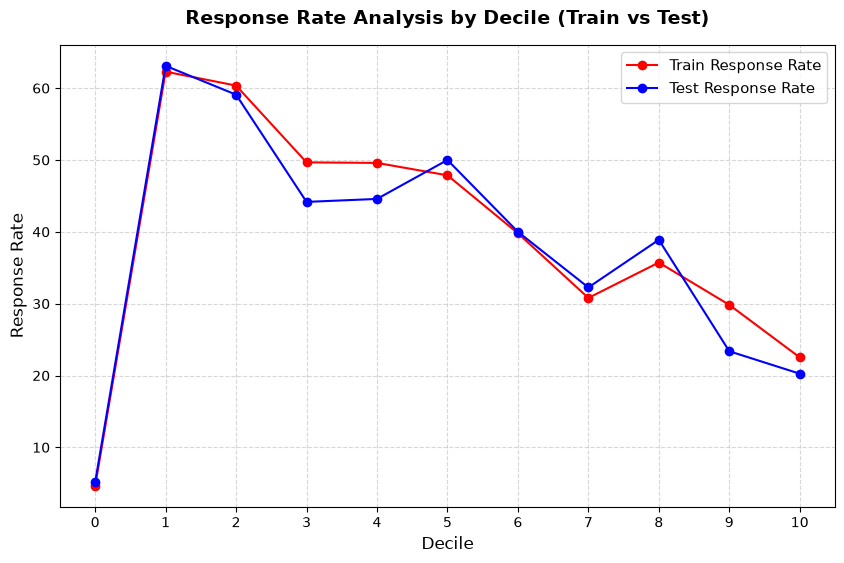

In [31]:
# 2. Plot both lines together
# Passing a list to 'y' plots multiple columns, and 'color' maps to them sequentially
ax = report.plot(
    x='decile_band', 
    y=['response_rate', 'test_response_rate'], 
    kind='line', 
    color=['red', 'blue'],      # response_rate = red, response_rate_test = blue
    marker='o',                 # Adds distinct data points to the lines
    figsize=(10, 6)
)

# 3. Customize titles, labels, and layout
plt.title('Response Rate Analysis by Decile (Train vs Test)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Decile', fontsize=12)
plt.ylabel('Response Rate', fontsize=12)

# Ensure all decile numbers display explicitly on the X-axis
plt.xticks(report['decile_band']) 

# Style the grid lines and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(['Train Response Rate', 'Test Response Rate'], loc='best', fontsize=11)

# 4. Display the chart
plt.show()



# Cleanup

In [32]:
con.close()
del decile
del pred_data
del mod_data
os.remove(f"{db_file}")
